<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><ul class="toc-item"><li><span><a href="#Packages" data-toc-modified-id="Packages-0.1"><span class="toc-item-num">0.1&nbsp;&nbsp;</span>Packages</a></span></li><li><span><a href="#Load-palatals-csv" data-toc-modified-id="Load-palatals-csv-0.2"><span class="toc-item-num">0.2&nbsp;&nbsp;</span>Load palatals csv</a></span></li></ul></li><li><span><a href="#Frequencies" data-toc-modified-id="Frequencies-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Frequencies</a></span></li><li><span><a href="#Plot" data-toc-modified-id="Plot-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Plot</a></span></li></ul></div>

## Packages

In [1]:
import os
import re

import codecs
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches

## Load palatals csv

In [2]:
entries_df = pd.read_csv('wikcionario_gl_pt_es_la-lh-nh_alt - latin.csv') 
entries_df

,gl,pt,es,la,gl_la,pt_la,es_la,notas,gl_la_2,pt_la_2,es_la_2,gl_simple,pt_simple,es_simple
0,orella,orelha,oreja,auricula,cul,cul,NaN,NaN,cl,cl,NaN,velar+l,velar+l,NaN
1,ollo,olho,ojo,oculus,cul,cul,NaN,NaN,cl,cl,NaN,velar+l,velar+l,NaN
2,ventrullo,barriga,barriga,ventriculum,cul,NaN,NaN,NaN,cl,NaN,NaN,velar+l,NaN,NaN
3,sobrecella,sobrancelha,ceja,supercilium,li,li,NaN,NaN,li,li,NaN,l+i,l+i,NaN
4,unlla,unha,uña,ungulam,ngul,ng,ng,NaN,ng,ng,ng,nasal+velar,nasal+velar,nasal+velar
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121,pulso,pulso,muñeca,pulsus\monneka,NaN,NaN,nn,es_substrato pré-romano,NaN,NaN,NaN,NaN,NaN,long_n
122,ano,ano,año,annus,NaN,NaN,nn,NaN,NaN,NaN,NaN,NaN,NaN,long_n
123,tinxir,tingir,teñir,tingere,NaN,NaN,ng,NaN,NaN,NaN,ng,NaN,NaN,nasal+velar
124,constrinxir,constringir,constreñir,constringere,NaN,NaN,ng,NaN,NaN,NaN,ng,NaN,NaN,nasal+velar


# Frequencies

In [3]:
gl_la_cat = pd.DataFrame()
gl_la_cat['counts'] = entries_df['gl_la'].value_counts()
gl_la_cat = gl_la_cat.reset_index()
gl_la_cat.columns = ['cat', 'gl_counts']
gl_la_cat['gl_counts'] = gl_la_cat.gl_counts/gl_la_cat["gl_counts"].sum()
gl_la_cat

,cat,gl_counts
0,cul,0.189189
1,li,0.189189
2,in,0.189189
3,ne,0.094595
4,ni,0.081081
5,gn,0.054054
6,num,0.040541
7,gul,0.027027
8,le,0.027027
9,sul,0.013514


In [4]:
pt_la_cat = pd.DataFrame()
pt_la_cat['counts'] = entries_df['pt_la'].value_counts()
pt_la_cat = pt_la_cat.reset_index()
pt_la_cat.columns = ['cat', 'pt_counts']
pt_la_cat['pt_counts'] = pt_la_cat.pt_counts/pt_la_cat["pt_counts"].sum()
pt_la_cat

,cat,pt_counts
0,in,0.200000
1,li,0.186667
2,cul,0.173333
3,ne,0.080000
4,ni,0.080000
5,gn,0.053333
6,num,0.040000
7,gul,0.026667
8,le,0.026667
9,ndi,0.013333


In [5]:
pt_la_cat = pt_la_cat.drop([12])

pt_la_cat['pt_counts'] = pt_la_cat.pt_counts/pt_la_cat["pt_counts"].sum()
pt_la_cat

,cat,pt_counts
0,in,0.202703
1,li,0.189189
2,cul,0.175676
3,ne,0.081081
4,ni,0.081081
5,gn,0.054054
6,num,0.040541
7,gul,0.027027
8,le,0.027027
9,ndi,0.013514


In [6]:
es_la_cat = pd.DataFrame()
es_la_cat['counts'] = entries_df['es_la'].value_counts()
es_la_cat = es_la_cat.reset_index()
es_la_cat.columns = ['cat', 'es_counts']
es_la_cat['es_counts'] = es_la_cat.es_counts/es_la_cat["es_counts"].sum()
es_la_cat

,cat,es_counts
0,ll,0.430769
1,li,0.092308
2,ne,0.092308
3,ng,0.061538
4,cul,0.061538
5,^pl,0.046154
6,nn,0.046154
7,l,0.030769
8,gn,0.030769
9,ni,0.030769


In [7]:
es_la_cat = es_la_cat.drop([11])

es_la_cat['es_counts'] = es_la_cat.es_counts/es_la_cat["es_counts"].sum()
es_la_cat

,cat,es_counts
0,ll,0.437500
1,li,0.093750
2,ne,0.093750
3,ng,0.062500
4,cul,0.062500
5,^pl,0.046875
6,nn,0.046875
7,l,0.031250
8,gn,0.031250
9,ni,0.031250


In [8]:
la_transform_df = pd.merge(gl_la_cat, pt_la_cat, how='outer', on='cat')
la_transform_df = pd.merge(la_transform_df, es_la_cat, how='outer', on='cat')

la_transform_df

,cat,gl_counts,pt_counts,es_counts
0,cul,0.189189,0.175676,0.062500
1,li,0.189189,0.189189,0.093750
2,in,0.189189,0.202703,0.015625
3,ne,0.094595,0.081081,0.093750
4,ni,0.081081,0.081081,0.031250
5,gn,0.054054,0.054054,0.031250
6,num,0.040541,0.040541,NaN
7,gul,0.027027,0.027027,NaN
8,le,0.027027,0.027027,NaN
9,sul,0.013514,0.013514,NaN


In [9]:
la_transform_df = la_transform_df.set_index(["cat"])
la_transform_df

,gl_counts,pt_counts,es_counts
cat,,,
cul,0.189189,0.175676,0.062500
li,0.189189,0.189189,0.093750
in,0.189189,0.202703,0.015625
ne,0.094595,0.081081,0.093750
ni,0.081081,0.081081,0.031250
gn,0.054054,0.054054,0.031250
num,0.040541,0.040541,NaN
gul,0.027027,0.027027,NaN
le,0.027027,0.027027,NaN


# Plot

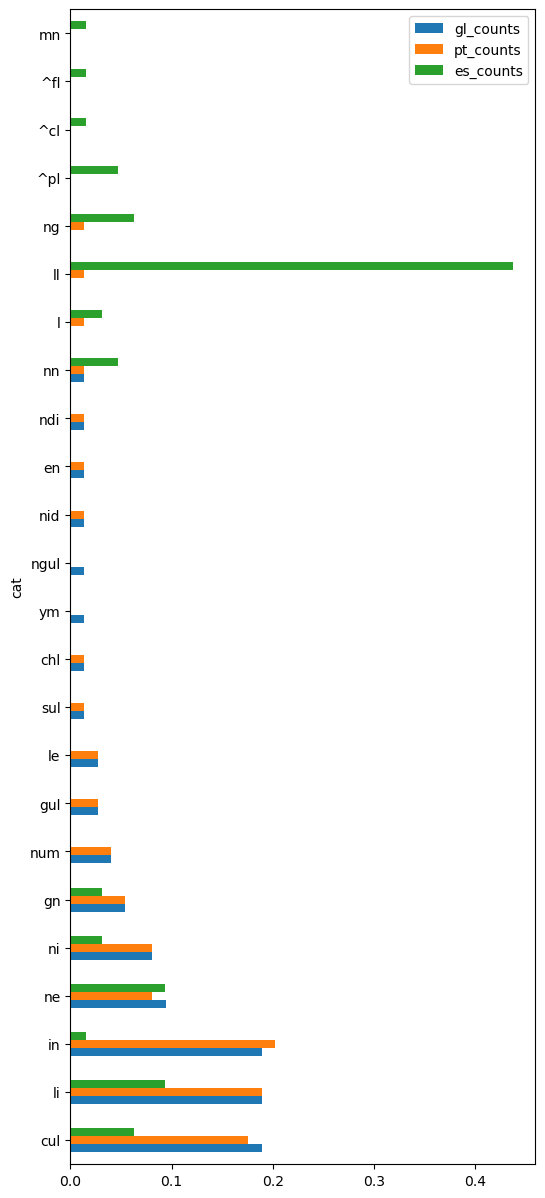

In [10]:
idx = la_transform_df.index.tolist()

la_transform_df.plot.barh(figsize=(6, 15))

plt.show()